# TruthGuard — Notebook 2/4
## Étape 2 : EDA Textuelle, Analyse par source & Qualité des données

> **Prérequis** : Avoir exécuté le Notebook 1 et avoir `df_raw` en mémoire (ou recharger le CSV).

## 5. EDA — Analyse textuelle (longueur, mots, phrases)

Chargé df_raw depuis C:\Users\PC\fake-news-app\notebook\Fake_news_net\data\df_raw_annotated.csv


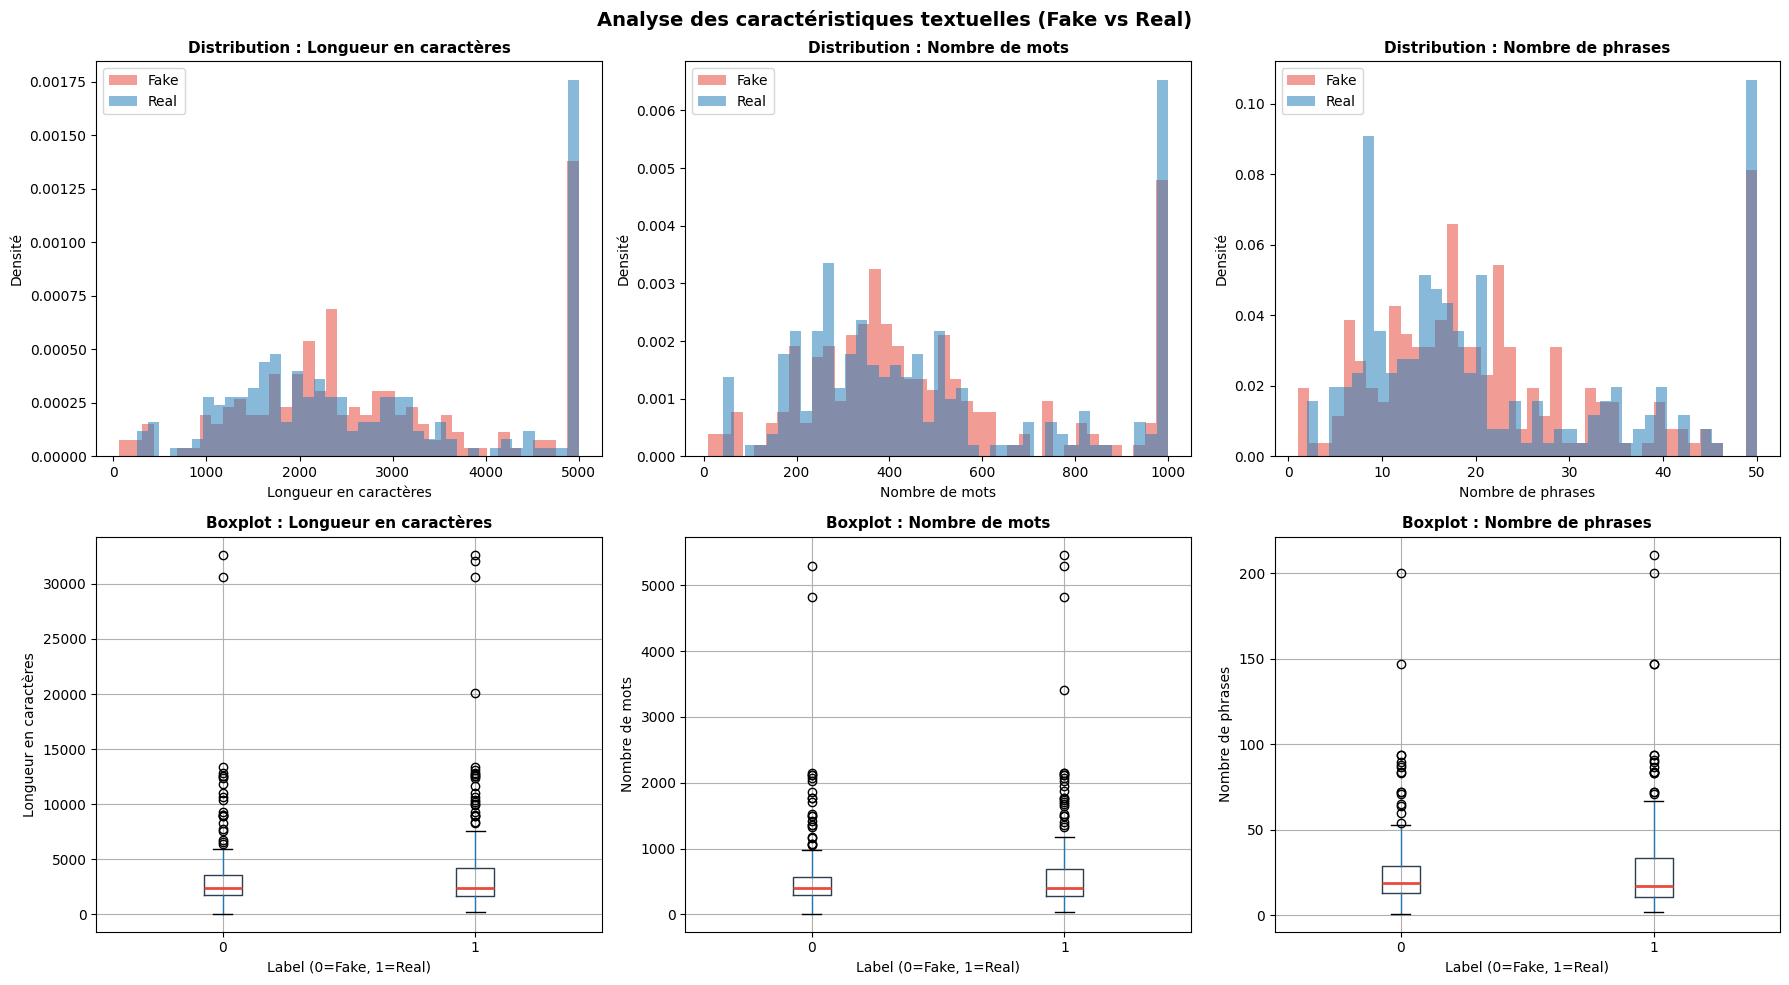


── Statistiques par label ──
      char_count                  word_count                sent_count         \
            mean  median      std       mean median     std       mean median   
label                                                                           
0        3486.20  2407.0  3749.84     574.91  408.0  604.28      25.43   19.0   
1        3855.54  2387.0  4554.96     634.44  405.0  747.32      26.74   17.0   

             avg_word_len               
         std         mean median   std  
label                                   
0      23.30         4.98   4.98  0.27  
1      28.94         5.00   4.99  0.26  


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
from pathlib import Path

try:
    df_raw
except NameError:
    data_path = None
    search_roots = [Path.cwd().resolve()] + [p for p in Path.cwd().resolve().parents] + [Path.home()]
    for root in search_roots:
        candidate = root / "notebook" / "Fake_news_net" / "data" / "df_raw_annotated.csv"
        if candidate.exists():
            data_path = candidate
            break
    if data_path is None:
        raise FileNotFoundError(
            f"df_raw non défini et le fichier notebook/Fake_news_net/data/df_raw_annotated.csv est introuvable. Recherche effectuée depuis : {[str(p) for p in search_roots]}"
        )
    df_raw = pd.read_csv(data_path)
    print(f"Chargé df_raw depuis {data_path}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ("char_count",   "Longueur en caractères",  5000),
    ("word_count",   "Nombre de mots",          1000),
    ("sent_count",   "Nombre de phrases",       50),
]

for col_idx, (metric, title, clip_val) in enumerate(metrics):
    ax_hist = axes[0, col_idx]
    ax_box  = axes[1, col_idx]

    for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
        data = df_raw[df_raw["label"] == lbl][metric].clip(upper=clip_val)
        ax_hist.hist(data, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax_hist.set_title(f"Distribution : {title}", fontsize=11, fontweight="bold")
    ax_hist.set_xlabel(title)
    ax_hist.set_ylabel("Densité")
    ax_hist.legend()

    df_raw.boxplot(column=metric, by="label", ax=ax_box,
                   boxprops=dict(color="#2c3e50"),
                   medianprops=dict(color="#e74c3c", linewidth=2))
    ax_box.set_title(f"Boxplot : {title}", fontsize=11, fontweight="bold")
    ax_box.set_xlabel("Label (0=Fake, 1=Real)")
    ax_box.set_ylabel(title)

plt.suptitle("Analyse des caractéristiques textuelles (Fake vs Real)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n── Statistiques par label ──")
print(df_raw.groupby("label")[["char_count", "word_count", "sent_count", "avg_word_len"]]
      .agg(["mean", "median", "std"]).round(2))

In [7]:
SEUIL_MIN_MOTS = 10
SEUIL_MAX_MOTS = 5000

trop_courts = df_raw[df_raw["word_count"] < SEUIL_MIN_MOTS]
trop_longs  = df_raw[df_raw["word_count"] > SEUIL_MAX_MOTS]

print(f"Articles < {SEUIL_MIN_MOTS} mots  : {len(trop_courts)} ({len(trop_courts)/len(df_raw)*100:.2f}%)")
print(f"Articles > {SEUIL_MAX_MOTS} mots : {len(trop_longs)} ({len(trop_longs)/len(df_raw)*100:.2f}%)")

if not trop_courts.empty:
    print("\nExemples d'articles trop courts :")
    print(trop_courts[["statement", "label", "source_df"]].head(3).to_string())

Articles < 10 mots  : 0 (0.00%)
Articles > 5000 mots : 3 (0.71%)


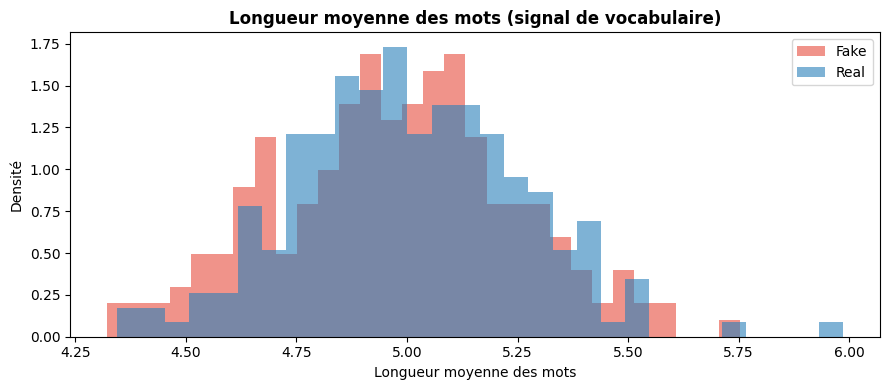

Longueur moy. mots — Fake : 4.976
Longueur moy. mots — Real : 5.005


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
    data = df_raw[df_raw["label"] == lbl]["avg_word_len"]
    ax.hist(data, bins=30, alpha=0.6, color=color, label=name, density=True)
ax.set_title("Longueur moyenne des mots (signal de vocabulaire)", fontweight="bold")
ax.set_xlabel("Longueur moyenne des mots")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.show()

print("Longueur moy. mots — Fake :", df_raw[df_raw["label"]==0]["avg_word_len"].mean().round(3))
print("Longueur moy. mots — Real :", df_raw[df_raw["label"]==1]["avg_word_len"].mean().round(3))

## 6. EDA — Analyse par source (BuzzFeed vs PolitiFact)

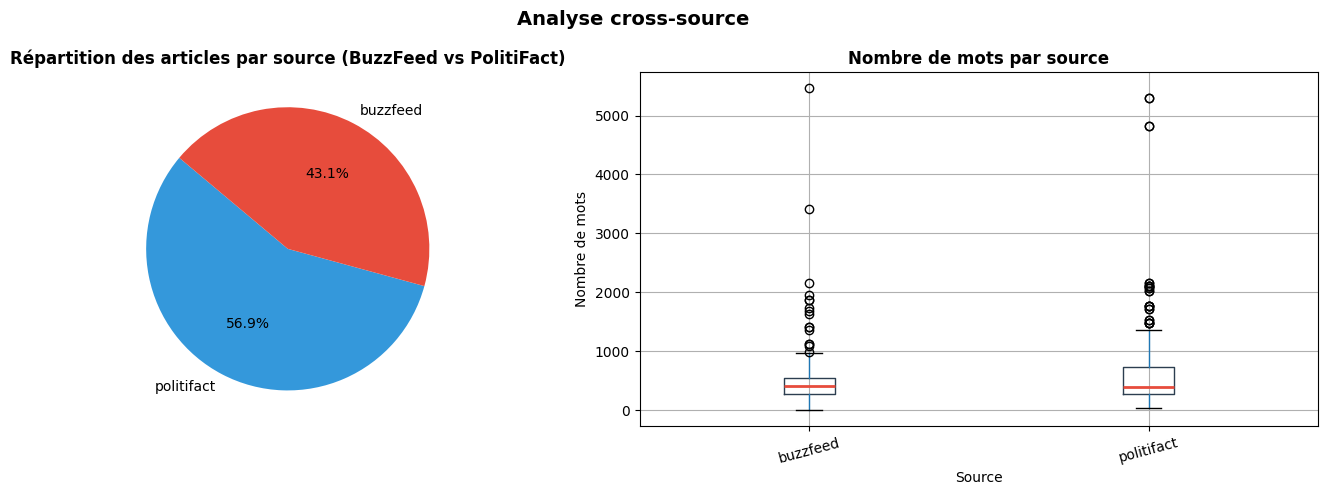


── Statistiques par source ──
           word_count              sent_count             
                 mean median count       mean median count
source_df                                                 
buzzfeed        541.4  414.5   182       23.8   18.0   182
politifact      652.7  390.5   240       27.8   18.0   240


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

src_counts = df_raw["source_df"].value_counts()
axes[0].pie(src_counts.values, labels=src_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=["#3498db", "#e74c3c", "#2ecc71", "#f39c12"])
axes[0].set_title("Répartition des articles par source (BuzzFeed vs PolitiFact)", fontweight="bold")

df_raw.boxplot(column="word_count", by="source_df", ax=axes[1],
               boxprops=dict(color="#2c3e50"),
               medianprops=dict(color="#e74c3c", linewidth=2))
axes[1].set_title("Nombre de mots par source", fontweight="bold")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Nombre de mots")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Analyse cross-source", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n── Statistiques par source ──")
print(df_raw.groupby("source_df")[["word_count", "sent_count"]]
      .agg(["mean", "median", "count"]).round(1))

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

def get_vocab(df_subset, n=10000):
    vec = CountVectorizer(max_features=n, stop_words="english")
    vec.fit(df_subset["statement"].fillna(""))
    return set(vec.vocabulary_.keys())

vocab_buzz  = get_vocab(df_raw[df_raw["source_df"] == "buzzfeed"])
vocab_poli  = get_vocab(df_raw[df_raw["source_df"] == "politifact"])

overlap = vocab_buzz & vocab_poli
union   = vocab_buzz | vocab_poli
jaccard = len(overlap) / len(union)

print(f"Vocabulaire BuzzFeed    : {len(vocab_buzz):,} mots")
print(f"Vocabulaire PolitiFact  : {len(vocab_poli):,} mots")
print(f"Vocabulaire commun      : {len(overlap):,} mots")
print(f"Jaccard similarity      : {jaccard:.3f}")
print("\n  Un faible Jaccard indique un shift de domaine → évaluation cross-domain importante.")

Vocabulaire BuzzFeed    : 9,902 mots
Vocabulaire PolitiFact  : 8,777 mots
Vocabulaire commun      : 5,161 mots
Jaccard similarity      : 0.382

  Un faible Jaccard indique un shift de domaine → évaluation cross-domain importante.


## 7. EDA — Analyse lexicale (TF-IDF, N-grams, Word clouds)

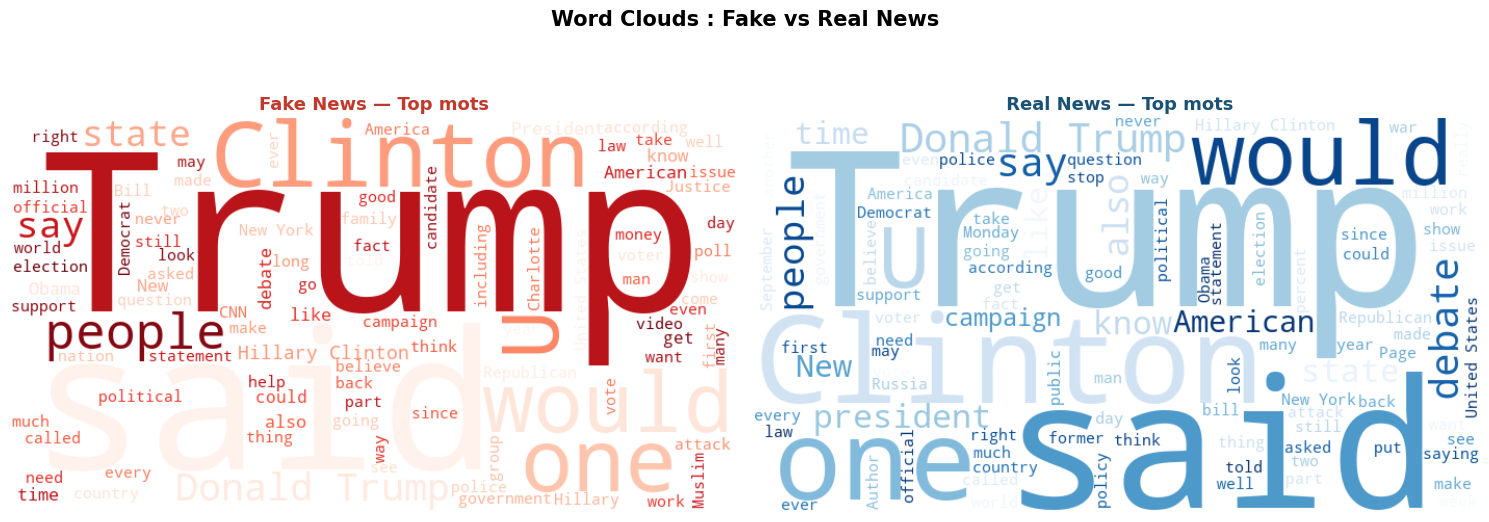

In [11]:
from nltk.corpus import stopwords
from wordcloud import WordCloud

fake_text = " ".join(df_raw[df_raw["label"] == 0]["statement"].fillna(""))
real_text = " ".join(df_raw[df_raw["label"] == 1]["statement"].fillna(""))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, text, title, color in zip(
    axes,
    [fake_text, real_text],
    ["Fake News — Top mots", " Real News — Top mots"],
    ["#c0392b", "#1a5276"]
):
    wc = WordCloud(
        width=700, height=380,
        background_color="white",
        stopwords=set(stopwords.words("english")),
        colormap="Reds" if "Fake" in title else "Blues",
        max_words=100
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=13, fontweight="bold", color=color)
    ax.axis("off")

plt.suptitle("Word Clouds : Fake vs Real News", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

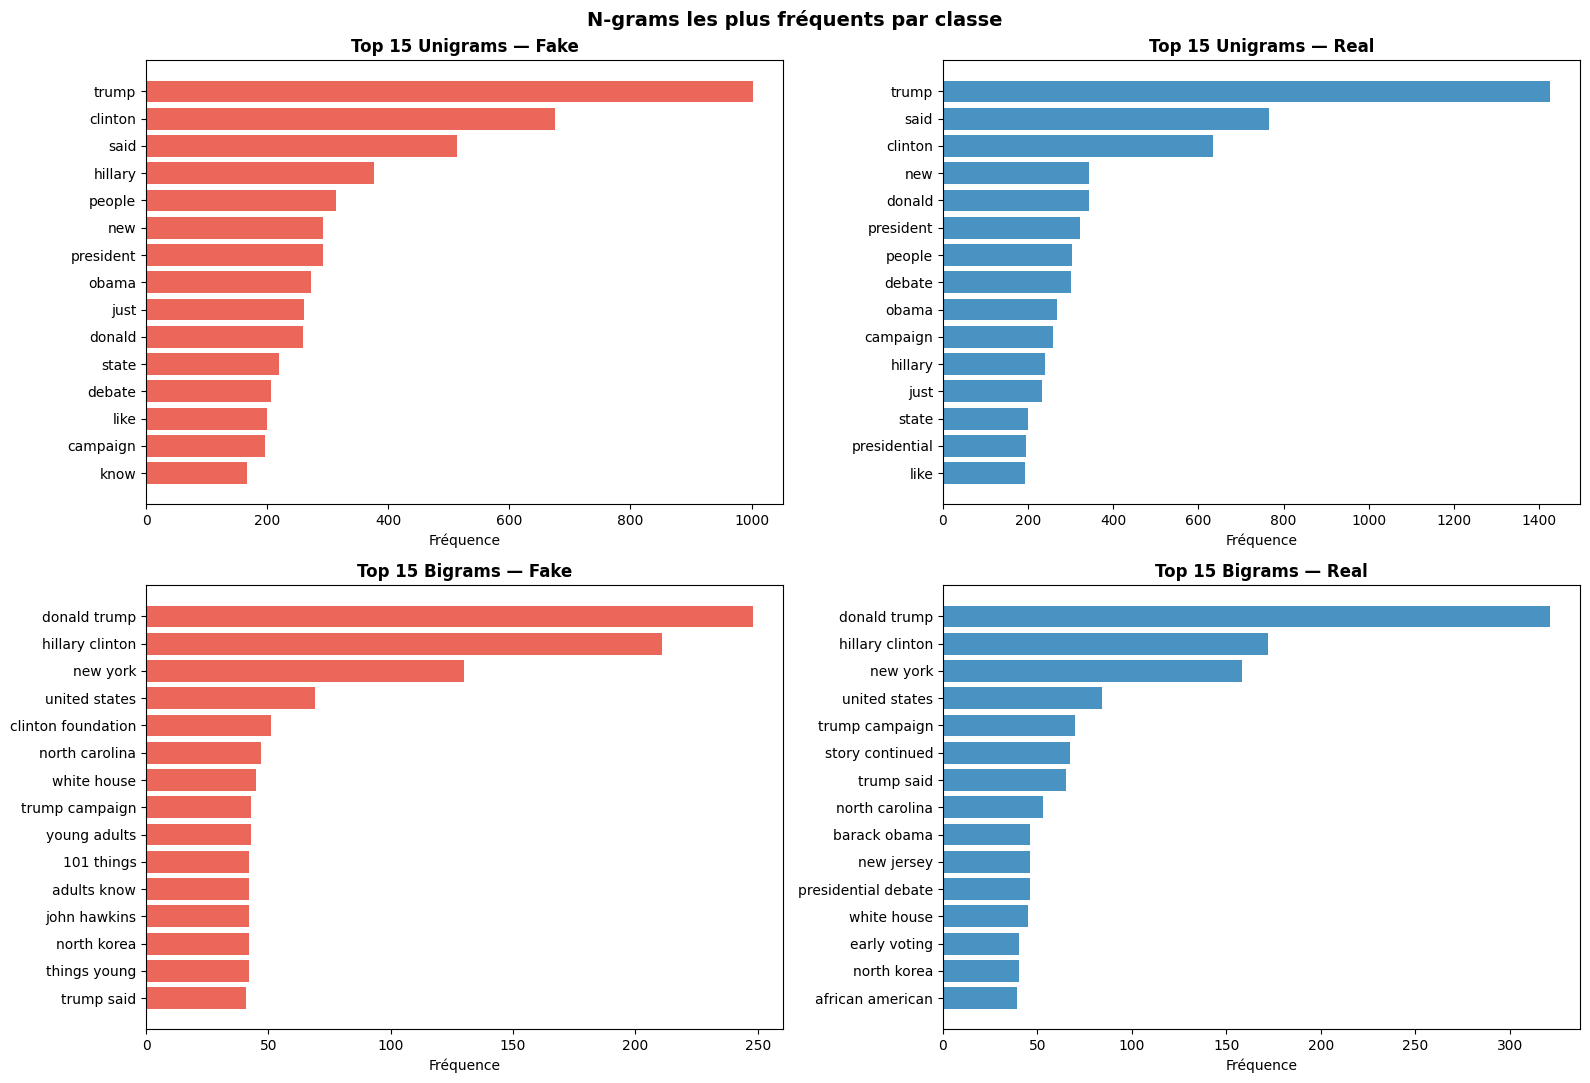

In [12]:
def top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english", max_features=50000)
    X   = vec.fit_transform(corpus)
    freq = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    df_ng = pd.DataFrame({"ngram": terms, "freq": freq})
    return df_ng.nlargest(top_k, "freq").reset_index(drop=True)

fake_corpus = df_raw[df_raw["label"] == 0]["statement"].fillna("")
real_corpus = df_raw[df_raw["label"] == 1]["statement"].fillna("")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for row, (n, label) in enumerate([(1, "Unigrams"), (2, "Bigrams")]):
    for col, (corpus, name, color) in enumerate([
        (fake_corpus, "Fake", "#e74c3c"),
        (real_corpus, "Real", "#2980b9")
    ]):
        ax   = axes[row, col]
        data = top_ngrams(corpus, n=n, top_k=15)
        ax.barh(data["ngram"][::-1], data["freq"][::-1], color=color, alpha=0.85)
        ax.set_title(f"Top 15 {label} — {name}", fontweight="bold")
        ax.set_xlabel("Fréquence")

plt.suptitle("N-grams les plus fréquents par classe", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

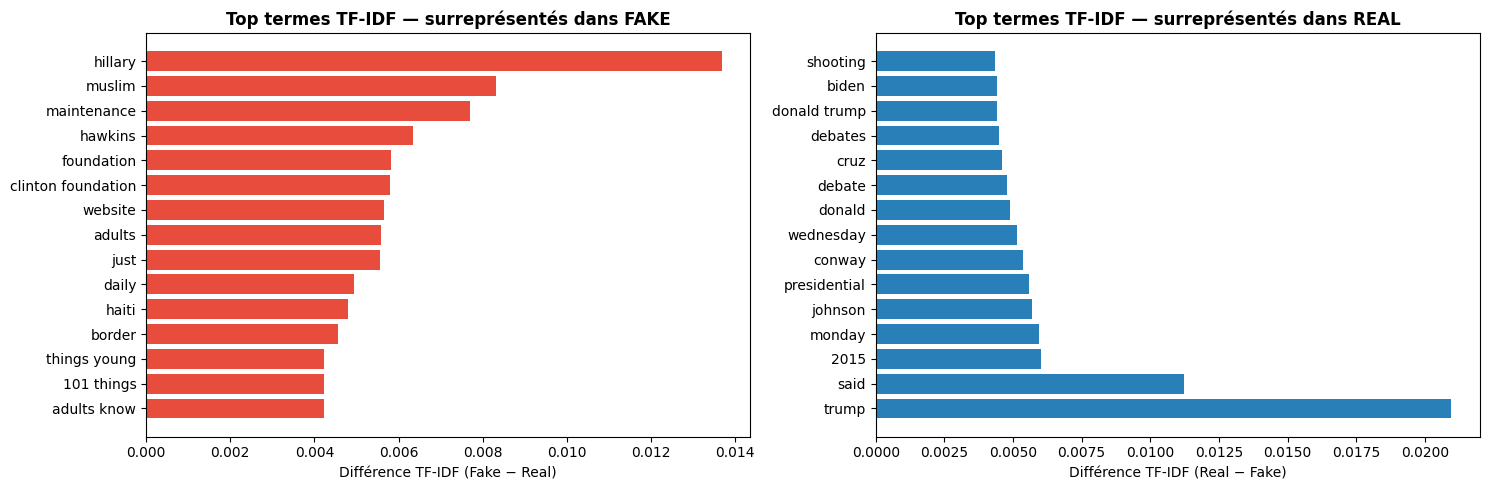

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec_tfidf = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1,2))
X_all = vec_tfidf.fit_transform(df_raw["statement"].fillna(""))
terms = vec_tfidf.get_feature_names_out()

mask_fake = (df_raw["label"] == 0).values
mask_real = (df_raw["label"] == 1).values

mean_fake = X_all[mask_fake].mean(axis=0).A1
mean_real = X_all[mask_real].mean(axis=0).A1
diff      = mean_fake - mean_real

top_fake_idx = np.argsort(diff)[-15:][::-1]
top_real_idx = np.argsort(diff)[:15]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh([terms[i] for i in top_fake_idx[::-1]], diff[top_fake_idx[::-1]], color="#e74c3c")
axes[0].set_title("Top termes TF-IDF — surreprésentés dans FAKE", fontweight="bold")
axes[0].set_xlabel("Différence TF-IDF (Fake − Real)")

axes[1].barh([terms[i] for i in top_real_idx], -diff[top_real_idx], color="#2980b9")
axes[1].set_title("Top termes TF-IDF — surreprésentés dans REAL", fontweight="bold")
axes[1].set_xlabel("Différence TF-IDF (Real − Fake)")

plt.tight_layout()
plt.show()

## 8. EDA — Qualité des données (NaN, doublons, bruit)

In [14]:
print("═" * 55)
print(" RAPPORT DE QUALITÉ DES DONNÉES")
print("═" * 55)

nan_counts = df_raw.isnull().sum()
nan_pct    = (nan_counts / len(df_raw) * 100).round(2)
print("\n1. Valeurs manquantes :")
print(pd.DataFrame({"NaN count": nan_counts, "NaN %": nan_pct})
      .query("`NaN count` > 0").to_string())

dupl_exact  = df_raw.duplicated(subset="statement").sum()
dupl_prefix = df_raw["statement"].str[:100].duplicated().sum()
print(f"\n2. Doublons (statement exact)  : {dupl_exact}")
print(f"   Quasi-doublons (100 premiers caractères) : {dupl_prefix}")

empty    = df_raw["statement"].str.strip().eq("").sum()
very_short = (df_raw["word_count"] < 5).sum()
print(f"\n3. Textes vides (après strip)  : {empty}")
print(f"   Textes très courts (<5 mots) : {very_short}")

df_raw["special_ratio"] = df_raw["statement"].apply(
    lambda x: sum(1 for c in str(x) if not c.isalnum() and c != ' ') / max(len(str(x)), 1)
)
noisy = (df_raw["special_ratio"] > 0.3).sum()
print(f"\n4. Textes très bruités (>30% car. spéciaux) : {noisy}")

html_pattern = re.compile(r'<[a-zA-Z][^>]*>')
has_html = df_raw["statement"].apply(lambda x: bool(html_pattern.search(str(x)))).sum()
print(f"\n5. Articles avec balises HTML résiduelles : {has_html}")

has_url = df_raw["statement"].str.contains(r'http|www\.', regex=True, na=False).sum()
print(f"\n6. Articles avec URLs résiduelles : {has_url}")

═══════════════════════════════════════════════════════
 RAPPORT DE QUALITÉ DES DONNÉES
═══════════════════════════════════════════════════════

1. Valeurs manquantes :
Empty DataFrame
Columns: [NaN count, NaN %]
Index: []

2. Doublons (statement exact)  : 133
   Quasi-doublons (100 premiers caractères) : 133

3. Textes vides (après strip)  : 0
   Textes très courts (<5 mots) : 0

4. Textes très bruités (>30% car. spéciaux) : 0

5. Articles avec balises HTML résiduelles : 1

6. Articles avec URLs résiduelles : 20


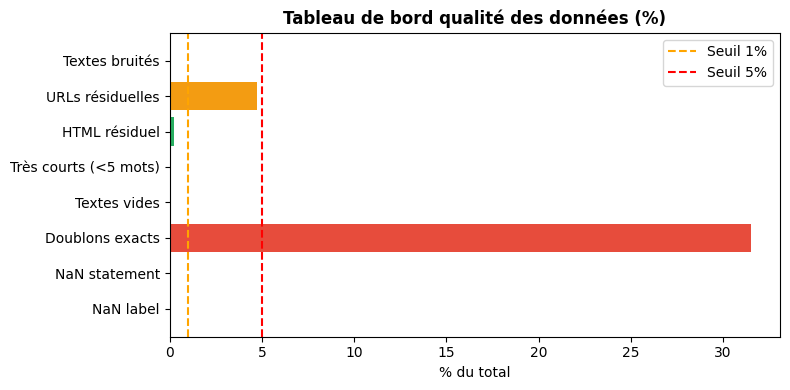

             Métrique  Nombre  % du total
            NaN label       0       0.000
        NaN statement       0       0.000
      Doublons exacts     133      31.517
         Textes vides       0       0.000
Très courts (<5 mots)       0       0.000
        HTML résiduel       1       0.237
     URLs résiduelles      20       4.739
       Textes bruités       0       0.000


In [15]:
quality_metrics = pd.DataFrame({
    "Métrique":  ["NaN label", "NaN statement", "Doublons exacts",
                  "Textes vides", "Très courts (<5 mots)",
                  "HTML résiduel", "URLs résiduelles", "Textes bruités"],
    "Nombre":    [
        df_raw["label"].isna().sum(),
        df_raw["statement"].isna().sum(),
        dupl_exact, empty, very_short,
        has_html, has_url, noisy
    ]
})
quality_metrics["% du total"] = (quality_metrics["Nombre"] / len(df_raw) * 100).round(3)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#27ae60" if v < 1 else ("#f39c12" if v < 5 else "#e74c3c")
              for v in quality_metrics["% du total"]]
ax.barh(quality_metrics["Métrique"], quality_metrics["% du total"], color=colors_bar)
ax.axvline(x=1, color="orange", linestyle="--", label="Seuil 1%")
ax.axvline(x=5, color="red",    linestyle="--", label="Seuil 5%")
ax.set_title("Tableau de bord qualité des données (%)", fontweight="bold")
ax.set_xlabel("% du total")
ax.legend()
plt.tight_layout()
plt.show()
print(quality_metrics.to_string(index=False))